<img src='https://docs.abstractsecurity.app/img/logos/logo-dark.svg' height='44'>

# Abstract AI-SOC Notebook

### One analyst workspace over the Abstract pipeline — hunt · investigate · enrich · report · act

A single, branded notebook that exercises **every Abstract use case** end-to-end:

| | |
|---|---|
| **Connect** | Abstract **REST API** *and* the Abstract **MCP server** (the way agents consume it) |
| **Hunt** | a reusable threat-hunting catalog over the normalized event stream + entity graph |
| **Investigate** | entity-360, blast radius (real-time vs LakeVilla replay), attack timeline, prediction |
| **Score** | continuous, decaying per-entity risk with trajectories + forecast |
| **Enrich** | authenticated OSINT (VirusTotal · Shodan · GreyNoise · AbuseIPDB · OTX · urlscan · Censys) + 24-engine keyless pivots |
| **Report** | analyst-ready incident report (Markdown + branded HTML) |
| **Act** | write back to Abstract — field-sets · views · insights · verdicts |

> Runs **offline** out of the box (synthetic Qakbot-style campaign). Add an Abstract key
> (`~/.abstract.env`) and OSINT keys (env vars) to light up the live paths. The engine is
> pure-stdlib; the notebook adds matplotlib / networkx / pandas (see `requirements.txt`).

## 0 · Setup & dependencies

In [1]:
# one-time (uncomment to install into the active kernel):
# %pip install -r requirements.txt
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.max_colwidth", 60); pd.set_option("display.max_rows", 40)

import matplotlib, networkx, numpy
print("matplotlib", matplotlib.__version__, "| networkx", networkx.__version__,
      "| numpy", numpy.__version__, "| pandas", pd.__version__)

matplotlib 3.11.0 | networkx 3.6.1 | numpy 2.4.6 | pandas 3.0.3


## 1 · Load the Abstract model engine

Normalize the mixed-source estate to a common shape, build the **entity graph**
(user / host / account / NHI / agent / IOC), run the **shift-left detections**,
orchestrate the **sub-agents**, and compute **continuous risk** + **efficiency**.

In [2]:
from pipeline import (normalize, Graph, run_detections, run_investigation,
                      continuous_scores, efficiency, IOCSet)
from data import events, IOCS, INCIDENT_START
import viz, identities as ID, hunts, enrichment

raw  = events()
norm = [normalize(i, r) for i, r in enumerate(raw)]
g = Graph()
for ev in norm:
    g.add(ev)
findings = run_detections(norm, IOCS)
inv      = run_investigation(g, findings, IOCS, INCIDENT_START, norm)
scores   = continuous_scores(norm, IOCS)
metrics  = efficiency(norm, findings)

print(f"{len(norm):,} events | {len(g.nodes)} entities | {len(findings)} findings | "
      f"{len(inv['subagents']['scoping']['victims'])} entities in blast radius")

5,018 events | 163 entities | 11 findings | 8 entities in blast radius


## 2 · Connect to Abstract — REST API *(optional, live)*

Reads the key from `~/.abstract.env` (outside the repo) or the environment. With no
key the notebook stays **offline** and every live cell falls back to the local model.
`LIVE` gates the authenticated paths below.

In [3]:
client = None
LIVE = False
try:
    from abstract_client import AbstractClient, ABSTRACT_ACCOUNT_ID
    client = AbstractClient("api")
    conn = client.connect()
    LIVE = bool(conn.get("ok"))
    print("Abstract REST:", conn, "| tenant:", ABSTRACT_ACCOUNT_ID or "(unset)")
except Exception as e:
    print("offline — no Abstract key set (", str(e)[:80], ")")

Abstract REST: {'ok': True, 'scheme': 'bearer', 'status': 200} | tenant: 12jW5BDyQR


## 3 · Connect to Abstract — **MCP server**

The same Abstract API over the **Model Context Protocol** — exactly how Claude /
Copilot / agents consume it. We launch the bundled stdio server
(`solution/mcp/abstract_mcp_server.py`), list its tools, and make a real call.
Set `ABSTRACT_MCP_URL` to point at a remote MCP endpoint instead.

In [4]:
from mcp_client import AbstractMCP
mcp = AbstractMCP()
print("MCP status:", mcp.status())

tools = mcp.list_tools()
tools_df = pd.DataFrame([t for t in tools if "name" in t])
display(tools_df[["name", "description"]] if "name" in tools_df.columns else tools_df)

# a keyless tool call, end-to-end through MCP (no Abstract key required):
piv = mcp.call("osint_pivots", indicator="185.220.101.45")
print("\nMCP call osint_pivots ->", "ok" if piv.get("ok") else piv.get("error"),
      "| pivots:", (piv.get("result") or {}).get("count"))

MCP status: {'ready': True, 'transport': 'stdio', 'target': '../../../solution/mcp/abstract_mcp_server.py'}


,name,description
0,abstract_verify,"Verify connectivity/auth; returns the current user, org ..."
1,abstract_acs_fields,List Abstract Common Schema (ACS) fields and types. Opti...
2,abstract_search_events,Search normalized Abstract events over the last `hours`....
3,abstract_list_workflows,"List Abstract ASTRO/ASE agentic workflows (e.g. Verdict,..."
4,abstract_get_insight_verdict,Fetch the stored agentic verdict for an Abstract insight...
5,abstract_run_verdict,Run Abstract's agentic Verdict workflow for an insight a...
6,osint_pivots,Curated OSINT/hacker-search-engine pivot links for an in...



MCP call osint_pivots -> ok | pivots: 11


## 4 · Live tenant explorer — views · field-sets · insights

When connected, browse the real saved **views**, **field-sets**, and **insights**
on the tenant. Offline, this shows what the queries would return.

In [5]:
if LIVE:
    views = (client.list_views().get("body", {}) or {}).get("views", [])
    fsets = (client.list_fieldsets().get("body", {}) or {}).get("fieldsets", [])
    ins   = client.list_insights(page_size=10).get("body", {}) or {}
    print(f"views={len(views)}  field-sets={len(fsets)}  "
          f"insights(total)={ins.get('metadata', {}).get('total_count')}")
    display(pd.DataFrame([{"name": v.get("name"), "tags": v.get("tags")} for v in views[:12]]))
    display(pd.DataFrame([{"nanoid": i.get("nanoid"), "severity": i.get("severity"),
                           "status": i.get("status"), "title": i.get("title")}
                          for i in ins.get("insights", [])[:10]]))
else:
    print("offline — set ~/.abstract.env to browse the live tenant.")
    print("Equivalent MCP reads:  mcp.call('abstract_search_events', hours=24)  ·  list_insights / list_views")

views=36  field-sets=13  insights(total)=12


,name,tags
0,WildFire / PAN Threat Research (Abstract model demo),None
1,[ABS-DEMO] GenAI — agent abuse / permission bypass,None
2,[ABS-DEMO] Supply Chain — CI token harvest + startup mod,None
3,[ABS-DEMO] Agentic — AI agent anomalous tool call / exfil,None
4,[ABS-DEMO] NHI — service token used from new ASN,None
5,[ABS-DEMO] Identity Exposure — stolen session / cookie r...,None
6,[ABS-DEMO] Threat Intel — ATT&CK technique sighting,None
7,[ABS-DEMO] Threat Intel — known-bad IP match,None
8,[ABS-DEMO] WildFire — report C2 IOC contact,None
9,[ABS-DEMO] WildFire — malicious verdict,None


,nanoid,severity,status,title
0,XJisOcJ9Iq,high,open,AWS CloudTrail Arbitrary Command Execution Through SSM S...
1,ZqPr29M28l,critical,open,[ABS-DEMO] Malware confirmed by 3 independent controls o...
2,IdOyv7zeZb,critical,open,[ABS-DEMO] Auth from C2 infrastructure 91.219.236.12 — l...
3,ZwMcLcq2cf,critical,open,[ABS-DEMO] host:ACME-LT-4471 contacted 5 known-bad IOC(s)
4,JajXp19e70,high,open,[ABS-DEMO] identity:jsmith@acme.com contacted 4 known-ba...
5,C9dyXn99fT,high,open,[ABS-DEMO] Beaconing ACME-LT-4471 → 91.219.236.12 (6 ses...
6,NyFyt25UWK,high,open,[ABS-DEMO] account:okta:jsmith@acme.com contacted 3 know...
7,Dn686HTG1U,medium,open,[ABS-DEMO] host:ACME-LT-2210 contacted 2 known-bad IOC(s)
8,pPeu0U8Tdx,medium,open,[ABS-DEMO] host:ACME-LT-8802 contacted 2 known-bad IOC(s)
9,GkqfI0LMMS,critical,open,[ABS-DEMO] Malware confirmed by 3 independent controls o...


## 5 · Campaign entity graph
User / host / account / NHI / AI-agent / IOC — node size scales with continuous risk.

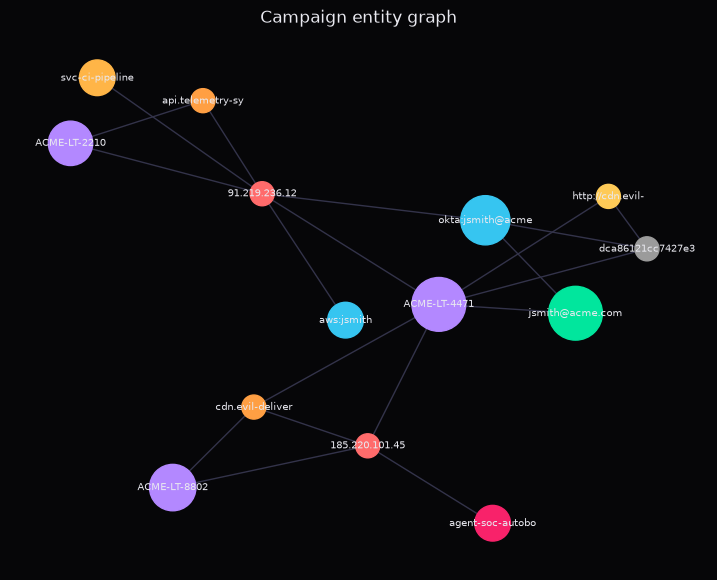

In [6]:
viz.draw_entity_graph(g, IOCS, scores);

## 6 · Continuous entity risk, trajectories & prediction

PREDICTED next targets: ['ACME-LT-2210', 'ACME-LT-8802']
rationale: contacted known C2 infrastructure with no local conviction yet — intervene before payload/execution


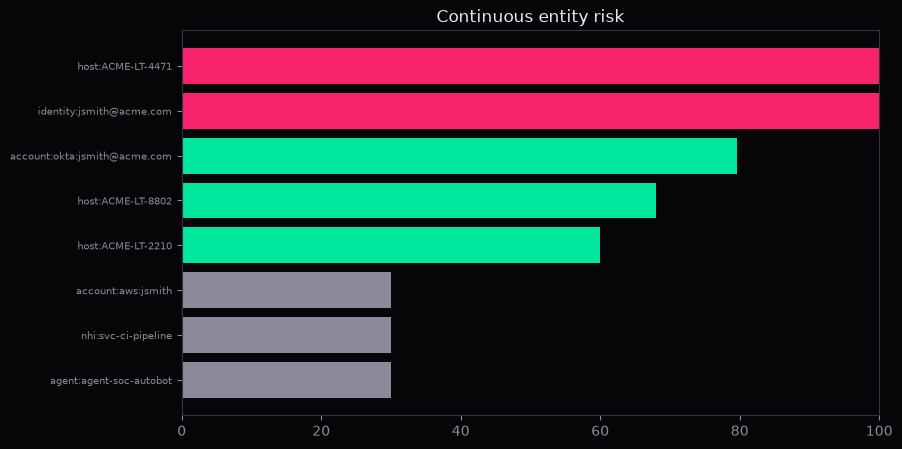

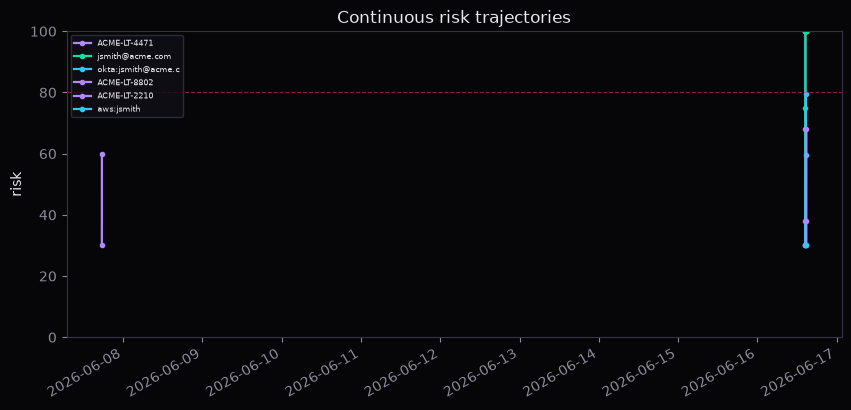

In [7]:
viz.draw_risk_bars(scores)
viz.draw_score_trajectories(scores, top=6)
print("PREDICTED next targets:", [p.split(':', 1)[1] for p in inv["prediction"]["predicted_next_targets"]])
print("rationale:", inv["prediction"]["rationale"])

## 7 · MITRE ATT&CK coverage *(live if connected)*

When connected, this pulls the tenant's real rule→technique coverage from
`/v3/rules/mitre` and aggregates per-tactic (the API reports `total`/`enabled`
per technique). Offline, it shows a representative coverage profile.

LIVE MITRE coverage: 662/683 techniques enabled across 14 tactics


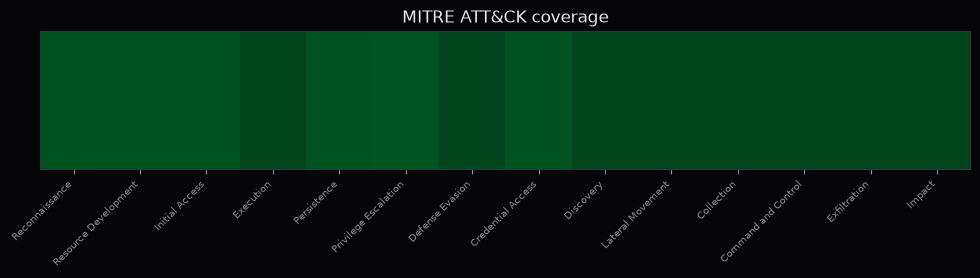

In [8]:
tactics = None
if LIVE:
    raw_tactics = ((client.mitre().get("body") or {}).get("tactics")) or []
    agg = []
    for ta in raw_tactics:
        techs = ta.get("techniques") or []
        total = sum(t.get("total", 0) for t in techs)
        enabled = sum(t.get("enabled", 0) for t in techs)
        if total:
            agg.append({"name": ta.get("name"), "total": total, "enabled": enabled})
    tactics = agg or None
    if tactics:
        cov = sum(t["enabled"] for t in tactics), sum(t["total"] for t in tactics)
        print(f"LIVE MITRE coverage: {cov[0]}/{cov[1]} techniques enabled across {len(tactics)} tactics")
if not tactics:
    tactics = [{"name": "Initial Access", "total": 10, "enabled": 9},
               {"name": "Execution", "total": 14, "enabled": 13},
               {"name": "Persistence", "total": 19, "enabled": 17},
               {"name": "Defense Evasion", "total": 42, "enabled": 38},
               {"name": "Cred Access", "total": 17, "enabled": 16},
               {"name": "C2", "total": 17, "enabled": 16},
               {"name": "Exfiltration", "total": 9, "enabled": 9}]
    print("offline — representative MITRE coverage profile")
viz.draw_mitre_heatmap(tactics);

## 8 · Attack-chain timeline

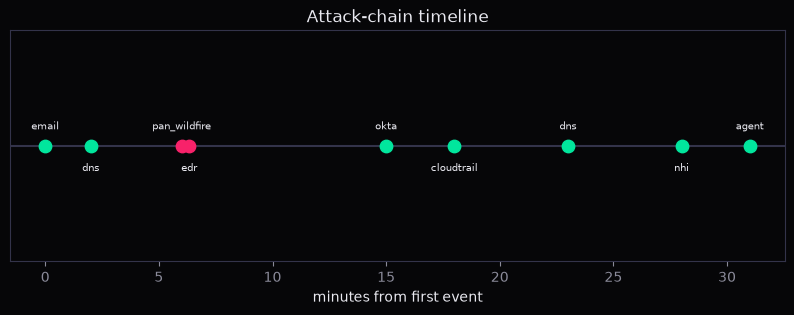

In [9]:
viz.draw_attack_timeline(norm);

## 9 · Detection coverage — findings

,rule,severity,risk,entities,title
0,verdict-fusion,critical,99,3,Malware confirmed by 3 independent controls on host:ACME...
1,ato-c2-bridge,critical,96,4,Auth from C2 infrastructure 91.219.236.12 — likely accou...
2,ioc-blast-match,high,95,6,host:ACME-LT-4471 contacted 5 known-bad IOC(s)
3,ioc-blast-match,high,87,5,identity:jsmith@acme.com contacted 4 known-bad IOC(s)
4,beaconing,high,82,2,"Beaconing ACME-LT-4471 → 91.219.236.12 (6 sessions, ~60s..."
5,ioc-blast-match,high,79,4,account:okta:jsmith@acme.com contacted 3 known-bad IOC(s)
6,ioc-blast-match,high,71,3,host:ACME-LT-2210 contacted 2 known-bad IOC(s)
7,ioc-blast-match,high,71,3,host:ACME-LT-8802 contacted 2 known-bad IOC(s)
8,ioc-blast-match,high,63,2,account:aws:jsmith contacted 1 known-bad IOC(s)
9,ioc-blast-match,high,63,2,nhi:svc-ci-pipeline contacted 1 known-bad IOC(s)


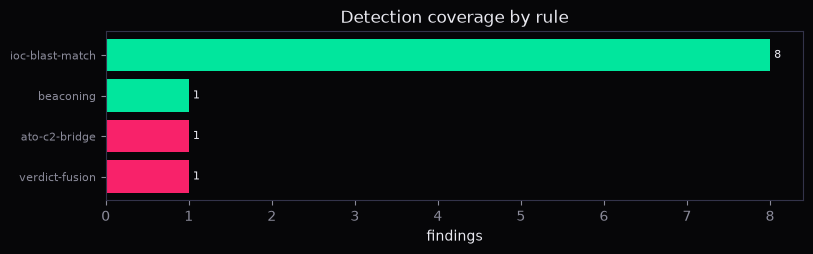

In [10]:
findings_df = pd.DataFrame([{
    "rule": f.rule, "severity": f.severity, "risk": f.risk,
    "entities": len(f.entities), "title": f.title} for f in findings])
display(findings_df.sort_values("risk", ascending=False).reset_index(drop=True))
viz.draw_findings_by_rule(findings);

## 10 · Threat-hunting library

A reusable catalog of hunts over the normalized stream + entity graph. Each maps to
something Abstract expresses as a detection rule or saved view. `hunts.run(key)` runs
one; `hunts.run_all()` runs the catalog.

In [11]:
ctx = hunts.make_context(norm, g, IOCS, scores)
display(pd.DataFrame(hunts.catalog()))

results = hunts.run_all(ctx)
rows = []
for key, hrows in results.items():
    for r in hrows:
        rows.append({"hunt": key, **{k: v for k, v in r.items() if k in
                     ("entity", "severity", "technique", "why")}})
hunt_df = pd.DataFrame(rows)
print(f"{len(hunt_df)} hunt rows across {len(results)} hunts")
display(hunt_df.head(30))

,key,title,tactic,technique,description
0,auth_from_c2,Auth from C2 infrastructure,Initial Access / Credential Access,T1078,Account takeover — principals authenticating from a know...
1,ioc_contact,Principal touched a known IOC,Command and Control,T1071,Continuous matchlist — any principal contacting a WildFi...
2,verdict_fusion,Multi-control malware conviction,Execution,T1204,Hosts convicted by ≥2 independent control families.
3,beaconing,C2 beaconing,Command and Control,T1071.001,"Periodic, low-volume sessions to a single destination."
4,high_risk_identities,High continuous-risk entities,—,—,Decaying per-entity risk score above threshold.
5,nhi_agent_exposure,NHI / AI-agent exposure,Persistence / Lateral Movement,T1078.004,Non-human and agentic identities reaching the internet /...
6,impossible_travel,Impossible travel,Credential Access,T1078,One principal authenticating from multiple IPs in a shor...
7,rare_destinations,Rare egress destinations,Command and Control,T1071,Destination IPs contacted by very few hosts.
8,dns_to_ioc,DNS to known-bad,Command and Control,T1071.004,Hosts resolving an IOC domain or to an IOC IP.


45 hunt rows across 9 hunts


,hunt,entity,severity,technique,why
0,auth_from_c2,account:aws:jsmith,critical,T1078,auth from C2 91.219.236.12
1,auth_from_c2,account:okta:jsmith@acme.com,critical,T1078,auth from C2 91.219.236.12
2,auth_from_c2,nhi:svc-ci-pipeline,critical,T1078,auth from C2 91.219.236.12
3,ioc_contact,host:ACME-LT-2210,high,T1071,contacted 2 IOC(s)
4,ioc_contact,account:okta:jsmith@acme.com,high,T1071,contacted 3 IOC(s)
5,ioc_contact,host:ACME-LT-4471,high,T1071,contacted 5 IOC(s)
6,ioc_contact,identity:jsmith@acme.com,high,T1071,contacted 4 IOC(s)
7,ioc_contact,account:aws:jsmith,high,T1071,contacted 1 IOC(s)
8,ioc_contact,host:ACME-LT-8802,high,T1071,contacted 2 IOC(s)
9,ioc_contact,nhi:svc-ci-pipeline,high,T1071,contacted 1 IOC(s)


## 11 · Entity-360 investigation

Pivot on any entity: its graph neighborhood, contributing findings, risk trajectory,
and raw event timeline — the analyst's single pane for one principal.

In [12]:
def investigate(entity):
    out = {"entity": entity, "kind": ID.classify_entity(
        {"type": entity.split(':', 1)[0], "id": entity.split(':', 1)[1]})}
    out["score"] = scores.get(entity, {}).get("final")
    out["neighbors"] = sorted(g.adj.get(entity, set()))[:12]
    out["findings"] = [f.title for f in findings if entity in f.entities]
    tl = [{"ts": str(ev.ts), "source": ev.source, "ocsf": ev.ocsf, "severity": ev.severity}
          for ev in norm if entity in ev.entity_keys()]
    out["events"] = len(tl)
    return out, pd.DataFrame(tl)

# investigate the highest-risk principal in the campaign
lead_entity = next(iter(scores))
summary, timeline_df = investigate(lead_entity)
import json as _json; print(_json.dumps(summary, indent=2, default=str))
display(timeline_df.head(15))

{
  "entity": "host:ACME-LT-4471",
  "kind": "machine_host",
  "score": 100.0,
  "neighbors": [
    "domain:cdn.evil-delivery.com",
    "hash:dca86121cc7427e375fd24fe5871d727a4604532c4f3a567b3c956a3b6b6e0c4",
    "identity:jsmith@acme.com",
    "ip:185.220.101.45",
    "ip:91.219.236.12",
    "process:ACME-LT-4471:2210:powershell.exe",
    "url:http://cdn.evil-delivery.com/inv/invoice_8841.exe"
  ],
  "findings": [
    "Malware confirmed by 3 independent controls on host:ACME-LT-4471",
    "host:ACME-LT-4471 contacted 5 known-bad IOC(s)",
    "Beaconing ACME-LT-4471 \u2192 91.219.236.12 (6 sessions, ~60s interval)"
  ],
  "events": 9
}


,ts,source,ocsf,severity
0,2026-06-16 14:28:00,dns,DNS Activity,high
1,2026-06-16 14:32:00,pan_wildfire,Detection Finding,critical
2,2026-06-16 14:32:20,edr,Detection Finding,high
3,2026-06-16 14:33:00,pan_traffic,Network Activity,informational
4,2026-06-16 14:34:00,pan_traffic,Network Activity,informational
5,2026-06-16 14:35:00,pan_traffic,Network Activity,informational
6,2026-06-16 14:36:00,pan_traffic,Network Activity,informational
7,2026-06-16 14:37:00,pan_traffic,Network Activity,informational
8,2026-06-16 14:38:00,pan_traffic,Network Activity,informational


## 12 · Blast radius — real-time vs LakeVilla replay, across all identity kinds

real-time : ['aws:jsmith', 'okta:jsmith@acme.com', 'agent-soc-autobot', 'ACME-LT-4471', 'ACME-LT-8802', 'jsmith@acme.com', 'svc-ci-pipeline']
replay    : ['ACME-LT-2210']
identity kinds: {'service_principal': 1, 'human_user': 2, 'ai_agent': 1, 'machine_host': 3, 'non_human_identity': 1}


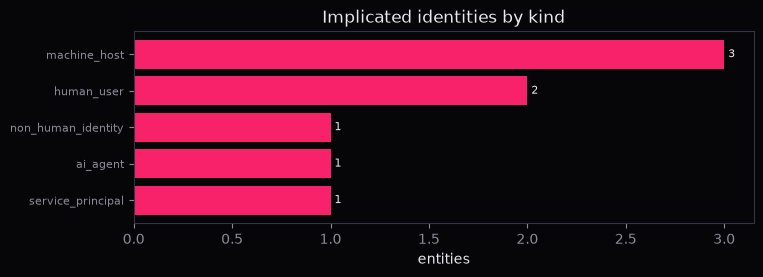

In [13]:
sc = inv["subagents"]["scoping"]
print("real-time :", [p.split(':', 1)[1] for p in sc["realtime"]])
print("replay    :", [p.split(':', 1)[1] for p in sc["historical"]])
counts = {}
for v in sc["victims"]:
    t, i = v.split(":", 1)
    k = ID.classify_entity({"type": t, "id": i})
    counts[k] = counts.get(k, 0) + 1
print("identity kinds:", counts)
viz.draw_identity_taxonomy(counts);

## 13 · Identity / NHI / agent taxonomy

The full spectrum a modern SOC must reason about — human, service, **non-human (NHI)**,
service principals, **AI agents**, stolen sessions — and which sources emit them.

In [14]:
tax_df = pd.DataFrame([{"kind": k, "description": v[0], "key_fields": ", ".join(v[1]),
                        "why_it_matters": v[3]} for k, v in ID.IDENTITY_TYPES.items()])
display(tax_df)

classified = pd.DataFrame([{
    "entity": k, "type": n["type"],
    "identity_kind": ID.classify_entity(n),
    "risk": scores.get(k, {}).get("final", 0)}
    for k, n in g.nodes.items() if n["type"] in ("identity", "account", "host", "nhi", "agent")])
display(classified.sort_values("risk", ascending=False).head(15).reset_index(drop=True))

,kind,description,key_fields,why_it_matters
0,human_user,Interactive person,"user_name, user.email","ATO, phishing, insider, MFA fatigue"
1,service_account,Non-interactive app/service login,"user_name, service.name","over-privileged, rarely rotated, lateral movement"
2,non_human_identity,NHI — tokens/keys/bots not tied to a person,"service.name, user_name, cloud.account_id","secret sprawl, token theft, supply-chain"
3,service_principal,Cloud app identity / managed identity,"cloud.account_id, user_name","consent abuse, role escalation, persistence"
4,machine_host,Device / workload / node,"host_name, host_address, host.os.name","C2 host, lateral pivot, crypto-mining"
5,ai_agent,"Autonomous AI/agentic identity (MCP, copilots)","service.name, process.name, user_name","prompt injection, tool abuse, agent identity sprawl"
6,session_cookie,Stolen web session / token (no password),"user.email, user_name, source_address",MFA bypass via session theft
7,api_key,Long-lived programmatic credential,"service.name, cloud.account_id","leaked-key abuse, exfil"
8,workload_identity,Federated workload (WIF / OIDC),"cloud.account_id, service.name",cross-cloud trust abuse


,entity,type,identity_kind,risk
0,identity:jsmith@acme.com,identity,human_user,100.0
1,host:ACME-LT-4471,host,machine_host,100.0
2,account:okta:jsmith@acme.com,account,human_user,79.6
3,host:ACME-LT-8802,host,machine_host,68.0
4,host:ACME-LT-2210,host,machine_host,60.0
5,agent:agent-soc-autobot,agent,ai_agent,30.0
6,nhi:svc-ci-pipeline,nhi,non_human_identity,30.0
7,account:aws:jsmith,account,service_principal,30.0
8,account:okta:user6@acme.com,account,human_user,0.0
9,account:okta:user36@acme.com,account,human_user,0.0


## 14 · OSINT enrichment workbench — authenticated + keyless pivots

Authenticated adapters (VirusTotal · Shodan · GreyNoise · AbuseIPDB · OTX · urlscan ·
Censys · HIBP) run when their key env var is set — **keys are read from the environment,
sent only to their provider, never logged**. Keyless one-click **pivot deep-links** (24
engines, distilled from *awesome-hacker-search-engines*) are always available.

In [15]:
from IPython.display import HTML, display
print("configured OSINT adapters (booleans only):")
display(pd.DataFrame([{"tool": k, "configured": v} for k, v in enrichment.available().items()]))

# clickable pivots for the campaign IOCs (no keys, no outbound calls):
ioc_samples = [("ip", "185.220.101.45"), ("ip", "91.219.236.12"),
               ("domain", "cdn.evil-delivery.com")]
html = ["<table style='font-family:JetBrains Mono,monospace;font-size:12px'>"]
for kind, val in ioc_samples:
    links = ID.pivot_urls(val, kind)
    cells = " · ".join(f"<a href='{d['url']}' target='_blank' style='color:#01e69d'>{name}</a>"
                       for name, d in list(links.items())[:8])
    html.append(f"<tr><td style='color:#f8226a;padding:4px 10px'><b>{kind}</b> {val}</td><td>{cells}</td></tr>")
html.append("</table>")
display(HTML("".join(html)))

if LIVE or any(enrichment.available().values()):
    print("\nLIVE enrichment (185.220.101.45):")
    res = enrichment.enrich("185.220.101.45", "ip")
    display(pd.DataFrame([{"tool": k, **(v.get("result", {}) if isinstance(v.get("result"), dict) else {"result": v.get("result"), "note": v.get("skipped")})}
                          for k, v in res["tools"].items()]))
else:
    print("\nset VT_API_KEY / SHODAN_API_KEY / ABUSEIPDB_API_KEY / … to run live enrichment.")

configured OSINT adapters (booleans only):


,tool,configured
0,VirusTotal,False
1,AbuseIPDB,False
2,Shodan,False
3,GreyNoise,True
4,AlienVault OTX,False
5,urlscan.io,False
6,Censys,False
7,Have I Been Pwned,False


ip 185.220.101.45,Shodan · Censys · ZoomEye · FOFA · Netlas · Onyphe · Criminal IP · VirusTotal
ip 91.219.236.12,Shodan · Censys · ZoomEye · FOFA · Netlas · Onyphe · Criminal IP · VirusTotal
domain cdn.evil-delivery.com,Shodan · Censys · ZoomEye · FOFA · Netlas · Onyphe · VirusTotal · Pulsedive



LIVE enrichment (185.220.101.45):


,tool,result,note,noise,authenticated
0,VirusTotal,NaN,no key (VT_API_KEY),NaN,NaN
1,AbuseIPDB,NaN,no key (ABUSEIPDB_API_KEY),NaN,NaN
2,Shodan,NaN,no key (SHODAN_API_KEY),NaN,NaN
3,GreyNoise,NaN,GreyNoise community now requires a free API key — set GR...,NaN,False
4,AlienVault OTX,NaN,no key (OTX_API_KEY),NaN,NaN
5,urlscan.io,NaN,no key (URLSCAN_API_KEY),NaN,NaN
6,Censys,NaN,no key (CENSYS_API_ID/CENSYS_API_SECRET),NaN,NaN


## 15 · Efficiency / value model *(modeled)*

{'total_events': 5018, 'forwarded_to_siem': 18, 'reduction_pct': 99.6, 'raw_alerts': 8, 'incidents': 1, 'fatigue_reduction_pct': 87.5}


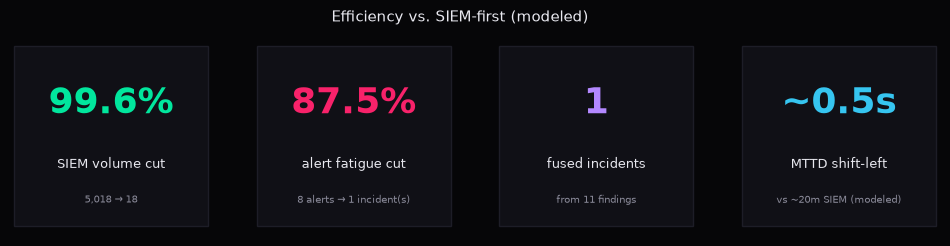

In [16]:
viz.draw_efficiency_panel(metrics)
print({k: metrics[k] for k in ("total_events", "forwarded_to_siem", "reduction_pct",
                               "raw_alerts", "incidents", "fatigue_reduction_pct")})

## 16 · What-if / hypotheticals
Quantify the WildFire-loop's value, and test an arbitrary 'if this were C2' hypothesis.

In [17]:
from pipeline import detect_verdict_fusion, detect_ioc_blast
vf = detect_verdict_fusion(norm)
known_wo = {e for f in vf for e in f.entities if e.split(':', 1)[0] in ('host', 'identity')}
with_loop = g.reachable_principals(IOCS.keys())
print('victims WITHOUT loop:', len(known_wo), '| WITH loop:', len(with_loop))

ip = next(n['id'] for n in g.nodes.values() if n['type'] == 'ip' and n['id'].startswith('52.'))
hyp = detect_ioc_blast(norm, IOCSet(set(), {ip}, set(), set()))
print(f'HYPOTHESIS: if {ip} were C2 -> {len(hyp)} entities implicated')

victims WITHOUT loop: 2 | WITH loop: 8
HYPOTHESIS: if 52.21.219.60 were C2 -> 41 entities implicated


## 17 · Generate the incident report (Markdown + branded HTML)

In [18]:
import report
norm2, g2, findings2, inv2, scores2, metrics2 = report.build()
md_text = report.markdown(findings2, inv2, scores2, metrics2)
open("investigation_report.md", "w").write(md_text)
open("investigation_report.html", "w").write(report.html_report(md_text, g2, scores2, inv2))
print(md_text[:900], "\n...\nwrote investigation_report.md + investigation_report.html")

# Incident Report — Qakbot-style intrusion (model demo)

**Lead finding:** Malware confirmed by 3 independent controls on host:ACME-LT-4471  
**Severity:** critical · **Risk:** 99/100 · **Triage:** true-positive (high confidence)

## Executive summary

A malware verdict corroborated by endpoint execution and C2 beaconing, with an identity authenticating from the same C2 infrastructure (account takeover). Detected in-stream before landing. **8 entities** implicated across 5 identity kinds; **2** predicted next targets.

## Detections (shift-left)

- **[99] verdict-fusion** — Malware confirmed by 3 independent controls on host:ACME-LT-4471  
  _controls agree: EDR, NGFW/WildFire, TI; user=jsmith@acme.com_
- **[96] ato-c2-bridge** — Auth from C2 infrastructure 91.219.236.12 — likely account takeover  
  _principals authenticating from a known C2 IP: account:aws:jsmith, account:okta:jsmith@a 
...
wrote investigation_report.md + investigation_report.html


## 18 · Write back to Abstract — field-set · view · insight

Turn the investigation into first-class platform objects via the REST API (needs a
write-scoped key). Idempotent + clearly `[ABS-DEMO]`-tagged so it's reversible.

In [19]:
if LIVE:
    fs = client.create_fieldset({
        "name": "[ABS-DEMO] Notebook investigation",
        "fields": ["type", "@timestamp", "severity", "user_name", "source_address",
                   "file.hash.sha256", "threat.technique_id", "message"],
        "tags": ["abs-demo", "notebook"]})
    fid = (fs.get("body") or {}).get("id")
    lead = findings[0]
    ins = client.create_insight({
        "title": "[ABS-DEMO] " + lead.title, "status": "open",
        "severity": lead.severity, "summary": lead.detail[:1500],
        "categories": ["detection"], "resolution": None,
        "mitre_attack_techniques": [{"id": "T1078", "name": "Valid Accounts", "sub_id": ""}]})
    print("field-set:", fid, "status", fs.get("status"))
    print("insight  :", (ins.get("body") or {}).get("nanoid"), "status", ins.get("status"))
    print("cleanup  : python3 generate_insights.py --cleanup  &&  python3 live_writeback.py --cleanup")
else:
    from pipeline import finding_to_abstract
    print("offline — payload preview (fires as-is once a write-scoped key is set):")
    import json as _json
    print(_json.dumps(finding_to_abstract(findings[0], scores), indent=2)[:900])

field-set: FFJRRN6LUj status 200
insight  : oA5jqqbxwW status 200
cleanup  : python3 generate_insights.py --cleanup  &&  python3 live_writeback.py --cleanup


## 19 · The closed loop

```
 Abstract pipeline ──(REST · MCP)──► this notebook ──(field-sets · views · insights · verdicts · reports)──► Abstract
   triggers:  new finding · new AIG IOC · hourly re-score · score-threshold → SOAR / agent
```

**Live** (with a key): tenant views/field-sets/insights, MITRE coverage, OSINT enrichment,
MCP tool calls, write-back. **Modeled in-engine**: replay, continuous scoring, prediction,
sub-agents, the incident narrative — see `DEMO-CATALOG.md` for the exact live-vs-modeled line.

Every capability here is also reachable as an **MCP tool** (`mcp.call(...)`) or a **REST**
call (`client...`), so the same logic drops into a Copilot/Claude agent, a Logic App
playbook, or a scheduled job — the notebook is just the analyst-facing surface.